# Taylor Polynomials Lab

Goals:

* Use `sympy` for symbolic algebra computations.
* Convert symbolic expressions to fuctions so they can be graphed.
* Write a function to produce Taylor Polynomials
* Use a graph to estimate bounds on the derivative and compute a bound on the remainder.



Import the following libraries.


In [7]:
import numpy as np
import sympy
import matplotlib.pyplot as plt

Run this code cell to define the following `sympy` expressions.  It also defines `x` to be a `sympy` symbol.

In [8]:
#define a symbolic variable x.
x=sympy.Symbol('x')

expr1 = sympy.cos(x**3-2*x)
expr2 = sympy.sin(x**3+2*x)
expr3 = sympy.sin(2*x**2)+sympy.cos(x)
expr4 = (x**3-x)*sympy.cos(x)
expr5 = x*sympy.sin(x**3+x)

Pick a different expression than each of your groupmates.  For the rest of this lab, it is referred to as *your function*.

## Q1

Copy/paste your `taylorpolynomial()` function from the prelab.  Then use it to print the degree 10 Taylor polynomial of your function, centered at 0.

In [9]:
#taylorpoly function
def taylorpoly(f,a,n):

  """
  f is sympy expression
  a is the center
  n is the degree of polynomial
  """

  poly = 0

  for k in range(n+1):

    der = sympy.diff(f,x,k)
    derval=der.subs(x,a)

    term = (derval/sympy.factorial(k))*(x-a)**k

    poly += term

  return poly

  #using expression 1,

tpoly_expr = taylorpoly(expr1,0,10)
print(tpoly_expr)

-1402*x**10/2025 + 401*x**8/315 - 173*x**6/90 + 8*x**4/3 - 2*x**2 + 1


## Q2

Using `sympy.lambdify()`, convert your function and its Taylor polynomial to functions that can be applied to `numpy` arrays.  Then plot both of them together on an axis.

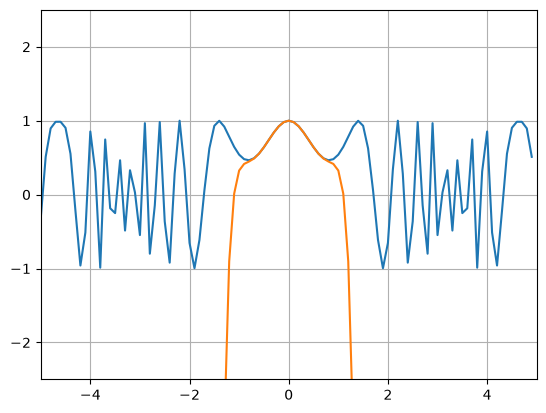

In [10]:
function_numpy = sympy.lambdify(x,expr1,'numpy')
tpoly_numpy = sympy.lambdify(x,tpoly_expr,'numpy')


x_1 = np.arange(-5,5,0.1)
y=function_numpy(x_1)
y_2=tpoly_numpy(x_1)


ax=plt.axes()
ax.plot(x_1,y)
ax.plot(x_1,y_2)

ax.set_xlim(-5,5)
ax.set_ylim(-2.5,2.5)
ax.grid()
plt.show()



## Q3

Get Sympy to compute the 11th derivative of your function, then lambdify and plot it.  Use the plot to approximate a bound $M$ such that $M$ is greater than the absolute value of the 11th derivative from 0 to 3.  Your $M$ does not have to be the optimal value, just reasonably close.

-80831520*x**5*(3*x**2 - 2)*cos(x*(x**2 - 2)) + 22453200*x**4*(3*x**2 - 2)**3*sin(x*(x**2 - 2)) - 134719200*x**4*sin(x*(x**2 - 2)) + 1496880*x**3*(3*x**2 - 2)**5*cos(x*(x**2 - 2)) - 89812800*x**3*(3*x**2 - 2)**2*cos(x*(x**2 - 2)) - 35640*x**2*(3*x**2 - 2)**7*sin(x*(x**2 - 2)) + 7484400*x**2*(3*x**2 - 2)**4*sin(x*(x**2 - 2)) - 89812800*x**2*(3*x**2 - 2)*sin(x*(x**2 - 2)) - 330*x*(3*x**2 - 2)**9*cos(x*(x**2 - 2)) + 166320*x*(3*x**2 - 2)**6*cos(x*(x**2 - 2)) - 9979200*x*(3*x**2 - 2)**3*cos(x*(x**2 - 2)) + 19958400*x*cos(x*(x**2 - 2)) + (3*x**2 - 2)**11*sin(x*(x**2 - 2)) - 990*(3*x**2 - 2)**8*sin(x*(x**2 - 2)) + 166320*(3*x**2 - 2)**5*sin(x*(x**2 - 2)) - 3326400*(3*x**2 - 2)**2*sin(x*(x**2 - 2))
Approximate maximum of |f^(11)(x)| on [0, 3]: 2.06e+15
Use M = 2064481970715458


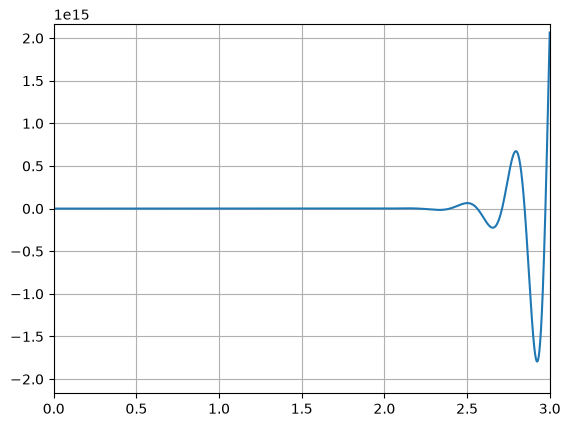

In [11]:
y_11 = sympy.diff(expr1, x, 11)
print(y_11)

y_11_plot = sympy.lambdify(x, y_11, 'numpy')
x_3 = np.linspace(0, 3, 10001)
y_11_values = y_11_plot(x_3)

max_abs_derivative = np.max(np.abs(y_11_values))
M = np.ceil(max_abs_derivative)
print(f"Approximate maximum of |f^(11)(x)| on [0, 3]: {max_abs_derivative:.2e}")
print(f"Use M = {M:.0f}")

ax = plt.axes()
ax.plot(x_3, y_11_values)
ax.set_xlim(0, 3)
ax.set_ylim(-1.05 * M, 1.05 * M)
ax.grid()
plt.show()

Q4

Use a code block to compute a bound on $|R_{10}(3)|$.  You will need your $M$ from Q3.

In [12]:
# Taylor's theorem remainder bound for the degree 10 polynomial at x = 3.
remainder_bound = M * 3**11 / sympy.factorial(11)
print(f"Bound on |R_10(3)|: {remainder_bound:.2e}")

Bound on |R_10(3)|: 9.16e+12
